In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(42)

In [3]:
import zipfile
import os

zip_file_path = '/content/archive (9).zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to: {extract_dir}")
print("Contents of extracted directory:")
print(os.listdir(extract_dir))

Files extracted to: /content/extracted_data
Contents of extracted directory:
['train', 'val', 'test']


Now that the files are extracted, we can identify the CSV file and load it.

In [4]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.ToTensor()
])

In [5]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="/content/extracted_data/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    root="/content/extracted_data/val",
    transform=test_transform
)

test_dataset = ImageFolder(
    root="/content/extracted_data/test",
    transform=test_transform
)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 48, 48])
torch.Size([32])


In [8]:
print(train_dataset.classes)

['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [9]:
import torch
import torch.nn as nn

class EmotionCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 7)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = EmotionCNN()
print(model)

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropo

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmotionCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 7])


In [12]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/20] Loss: 1.7557 Train Acc: 27.25%
Epoch [2/20] Loss: 1.5711 Train Acc: 36.98%
Epoch [3/20] Loss: 1.5005 Train Acc: 39.33%
Epoch [4/20] Loss: 1.4611 Train Acc: 40.87%
Epoch [5/20] Loss: 1.4303 Train Acc: 41.75%
Epoch [6/20] Loss: 1.4120 Train Acc: 42.55%
Epoch [7/20] Loss: 1.3986 Train Acc: 43.53%
Epoch [8/20] Loss: 1.3800 Train Acc: 43.89%
Epoch [9/20] Loss: 1.3641 Train Acc: 44.70%
Epoch [10/20] Loss: 1.3555 Train Acc: 44.71%
Epoch [11/20] Loss: 1.3381 Train Acc: 46.20%
Epoch [12/20] Loss: 1.3331 Train Acc: 46.39%
Epoch [13/20] Loss: 1.3254 Train Acc: 46.56%
Epoch [14/20] Loss: 1.3107 Train Acc: 47.79%
Epoch [15/20] Loss: 1.3061 Train Acc: 47.76%
Epoch [16/20] Loss: 1.2944 Train Acc: 48.24%
Epoch [17/20] Loss: 1.2727 Train Acc: 49.33%
Epoch [18/20] Loss: 1.2612 Train Acc: 49.98%
Epoch [19/20] Loss: 1.2475 Train Acc: 50.82%
Epoch [20/20] Loss: 1.2256 Train Acc: 52.41%


In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_acc = 100 * correct / total

print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 53.13%


In [14]:
torch.save(model.state_dict(), "emotion_cnn.pth")

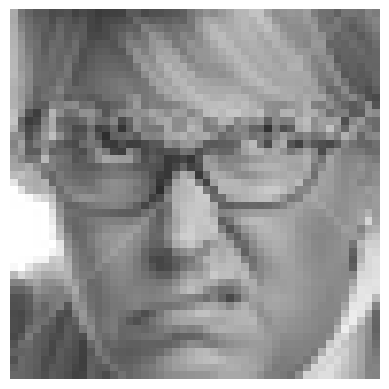

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/extracted_data/test/Angry/32298.png").convert("RGB")

plt.imshow(image)
plt.axis("off");

In [17]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

image_tensor = transform(image)

In [18]:
print(image_tensor.shape)

torch.Size([3, 48, 48])


In [19]:
image_tensor = image_tensor.unsqueeze(0)

print(image_tensor.shape)

torch.Size([1, 3, 48, 48])


In [20]:
class_names = train_dataset.classes

model.eval()

with torch.no_grad():

    image_tensor = image_tensor.to(device)

    output = model(image_tensor)

    predicted_class = torch.argmax(output, dim=1).item()

print("Predicted emotion:", class_names[predicted_class])

Predicted emotion: Sad


In [21]:
import torch.nn.functional as F

model.eval()

with torch.no_grad():

    image_tensor = image_tensor.to(device)

    output = model(image_tensor)

    probabilities = F.softmax(output, dim=1)

    confidence, predicted_class = torch.max(probabilities, dim=1)

print("Emotion:", class_names[predicted_class.item()])
print("Confidence:", f"{confidence.item() * 100:.2f}%")

Emotion: Sad
Confidence: 32.21%
